# A/B Testing Analysis #

## Import Libraries ##

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

## Load Dataset ##

In [22]:
data = pd.read_csv("Discount_AB_Test.csv")
data.head()

,Customer_ID,Variant,Price,Discount_Applied,Converted_Flag,Order_Value,Revenue,Unnamed: 7,Unnamed: 8
0,1,10% Discount,4312.56,0.1,0,0.0,0.0,NaN,NaN
1,2,20% Discount,2725.33,0.2,0,0.0,0.0,NaN,NaN
2,3,20% Discount,1379.60,0.2,0,0.0,0.0,NaN,NaN
3,4,20% Discount,3814.89,0.2,0,0.0,0.0,NaN,NaN
4,5,10% Discount,2384.05,0.1,0,0.0,0.0,NaN,NaN


In [24]:
data.head(15)

,Customer_ID,Variant,Price,Discount_Applied,Converted_Flag,Order_Value,Revenue,Unnamed: 7,Unnamed: 8
0,1,10% Discount,4312.56,0.1,0,0.00,0.00,NaN,NaN
1,2,20% Discount,2725.33,0.2,0,0.00,0.00,NaN,NaN
2,3,20% Discount,1379.60,0.2,0,0.00,0.00,NaN,NaN
3,4,20% Discount,3814.89,0.2,0,0.00,0.00,NaN,NaN
4,5,10% Discount,2384.05,0.1,0,0.00,0.00,NaN,NaN
5,6,10% Discount,3175.82,0.1,0,0.00,0.00,NaN,NaN
6,7,10% Discount,982.69,0.1,1,972.12,972.12,NaN,NaN
7,8,20% Discount,3342.13,0.2,1,2625.83,2625.83,NaN,NaN
8,9,20% Discount,2180.98,0.2,0,0.00,0.00,NaN,NaN
9,10,20% Discount,2003.85,0.2,0,0.00,0.00,NaN,NaN


## Initial Data Checks ##

In [28]:
print("Dataset Shape:", data.shape)
print("\nData Types:\n", data.dtypes)
print("\nMissing Values:\n", data.isnull().sum())
print("\nSample Data:\n", data.head())

Dataset Shape: (50000, 9)

Data Types:
 Customer_ID           int64
Variant              object
Price               float64
Discount_Applied    float64
Converted_Flag        int64
Order_Value         float64
Revenue             float64
Unnamed: 7          float64
Unnamed: 8          float64
dtype: object

Missing Values:
 Customer_ID             0
Variant                 0
Price                   0
Discount_Applied        0
Converted_Flag          0
Order_Value             0
Revenue                 0
Unnamed: 7          50000
Unnamed: 8          50000
dtype: int64

Sample Data:
    Customer_ID       Variant    Price  Discount_Applied  Converted_Flag  \
0            1  10% Discount  4312.56               0.1               0   
1            2  20% Discount  2725.33               0.2               0   
2            3  20% Discount  1379.60               0.2               0   
3            4  20% Discount  3814.89               0.2               0   
4            5  10% Discount  2384.05  

## DATA CLEANING ##

In [31]:
data = data.dropna(axis=1, how="all")
# Check variant split
print("\nVariant Distribution:\n", data["Variant"].value_counts())


Variant Distribution:
 Variant
10% Discount    25053
20% Discount    24947
Name: count, dtype: int64


## Split Control and Treatment ##

In [38]:
control = data[data["Variant"] == "10% Discount"]
treatment = data[data["Variant"] == "20% Discount"]

n_control = len(control)
n_treatment = len(treatment)

In [40]:
n_control

25053

In [42]:
n_treatment

24947

## CONVERSION RATE ANALYSIS ##

In [49]:
control_conv = control["Converted_Flag"].mean()
treatment_conv = treatment["Converted_Flag"].mean()
conversion_lift = (treatment_conv - control_conv) / control_conv

In [51]:
print("\nConversion Rate (10%):", round(control_conv, 4))
print("Conversion Rate (20%):", round(treatment_conv, 4))
print("Conversion Lift:", round(conversion_lift * 100, 2), "%")


Conversion Rate (10%): 0.182
Conversion Rate (20%): 0.2535
Conversion Lift: 39.25 %


## STATISTICAL TEST – CONVERSION ##

### Two-Proportion Z-Test ###

In [58]:
successes = np.array([
    control["Converted_Flag"].sum(),
    treatment["Converted_Flag"].sum()
])

In [64]:
samples = np.array([n_control, n_treatment])
z_stat, p_conv = proportions_ztest(successes, samples)

In [66]:
print("\nZ-statistic:", round(z_stat, 4))
print("P-value (Conversion):", p_conv)


Z-statistic: -19.3565
P-value (Conversion): 1.795293281304711e-83


## REVENUE ANALYSIS ##

In [69]:
control_rpu = control["Revenue"].mean()
treatment_rpu = treatment["Revenue"].mean()

In [71]:
print("\nRevenue per User (10%):", round(control_rpu, 2))
print("Revenue per User (20%):", round(treatment_rpu, 2))


Revenue per User (10%): 456.71
Revenue per User (20%): 558.62


## STATISTICAL TEST – REVENUE ##
### Two-sample Welch T-Test ###

In [75]:
t_stat, p_rev = stats.ttest_ind(
    control["Revenue"],
    treatment["Revenue"],
    equal_var=False
)

In [77]:
print("\nT-statistic (Revenue):", round(t_stat, 4))
print("P-value (Revenue):", p_rev)


T-statistic (Revenue): -10.4381
P-value (Revenue): 1.7648797638580032e-25


## Visualization - Conversion Rate ##

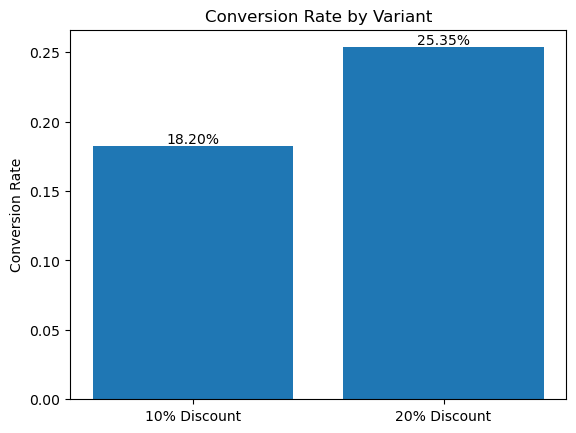

In [82]:
plt.figure()
bars = plt.bar(
    ["10% Discount", "20% Discount"],
    [control_conv, treatment_conv]
)
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by Variant")

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2%}",   # percentage format
        ha="center",
        va="bottom"
    )
plt.show()

## Revenue Distribution ##

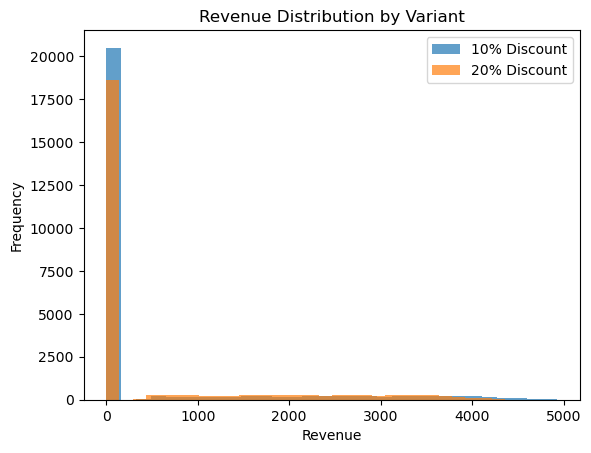

In [89]:
plt.figure()
plt.hist(control["Revenue"], bins=30, alpha=0.7, label="10% Discount")
plt.hist(treatment["Revenue"], bins=30, alpha=0.7, label="20% Discount")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.title("Revenue Distribution by Variant")
plt.legend()
plt.show()

## Revenue distribution by Variant ##

In [91]:
revenue_summary = pd.DataFrame({
    "Metric": [
        "Users",
        "Mean Revenue",
        "Median Revenue",
        "Std Deviation",
        "Min Revenue",
        "25th Percentile",
        "75th Percentile",
        "Max Revenue"
    ],
    "10% Discount": [
        control["Revenue"].count(),
        control["Revenue"].mean(),
        control["Revenue"].median(),
        control["Revenue"].std(),
        control["Revenue"].min(),
        control["Revenue"].quantile(0.25),
        control["Revenue"].quantile(0.75),
        control["Revenue"].max()
    ],
    "20% Discount": [
        treatment["Revenue"].count(),
        treatment["Revenue"].mean(),
        treatment["Revenue"].median(),
        treatment["Revenue"].std(),
        treatment["Revenue"].min(),
        treatment["Revenue"].quantile(0.25),
        treatment["Revenue"].quantile(0.75),
        treatment["Revenue"].max()
    ]
})

# Round values for better readability
revenue_summary = revenue_summary.round(2)

print(revenue_summary)

            Metric  10% Discount  20% Discount
0            Users      25053.00      24947.00
1     Mean Revenue        456.71        558.62
2   Median Revenue          0.00          0.00
3    Std Deviation       1090.46       1092.75
4      Min Revenue          0.00          0.00
5  25th Percentile          0.00          0.00
6  75th Percentile          0.00        454.42
7      Max Revenue       4926.72       4359.08


## SUMMARY TABLE ##

In [95]:
summary = pd.DataFrame({
    "Metric": ["Users", "Conversion Rate", "Revenue per User"],
    "10% Discount": [n_control, control_conv, control_rpu],
    "20% Discount": [n_treatment, treatment_conv, treatment_rpu]
})

print("\nSUMMARY TABLE:\n")
print(summary)


SUMMARY TABLE:

             Metric  10% Discount  20% Discount
0             Users  25053.000000  24947.000000
1   Conversion Rate      0.182014      0.253457
2  Revenue per User    456.710665    558.624247


## Confidence Interval for Conversion Rate ##

In [100]:
# Control group CI
control_success = control["Converted_Flag"].sum()
control_total = len(control)

control_ci_low, control_ci_high = proportion_confint(
    control_success,
    control_total,
    alpha=0.05,
    method="wilson"
)

# Treatment group CI
treatment_success = treatment["Converted_Flag"].sum()
treatment_total = len(treatment)

treatment_ci_low, treatment_ci_high = proportion_confint(
    treatment_success,
    treatment_total,
    alpha=0.05,
    method="wilson"
)

In [102]:
print("Conversion Rate CI (10% Discount):",
      round(control_ci_low, 4), "-", round(control_ci_high, 4))
print("Conversion Rate CI (20% Discount):",
      round(treatment_ci_low, 4), "-", round(treatment_ci_high, 4))

Conversion Rate CI (10% Discount): 0.1773 - 0.1868
Conversion Rate CI (20% Discount): 0.2481 - 0.2589


## Confidence Interval for Revenue per User ##

In [105]:
def mean_confidence_interval(data, confidence=0.95):
    mean = np.mean(data)
    sem = stats.sem(data)
    margin = sem * stats.t.ppf((1 + confidence) / 2, len(data) - 1)
    return mean - margin, mean + margin

control_rev_ci = mean_confidence_interval(control["Revenue"])
treatment_rev_ci = mean_confidence_interval(treatment["Revenue"])

In [107]:
print("Revenue CI (10% Discount):",
      round(control_rev_ci[0], 2), "-", round(control_rev_ci[1], 2))
print("Revenue CI (20% Discount):",
      round(treatment_rev_ci[0], 2), "-", round(treatment_rev_ci[1], 2))

Revenue CI (10% Discount): 443.21 - 470.21
Revenue CI (20% Discount): 545.06 - 572.18


# POWER ANALYSIS #

## Power Analysis for Conversion Rate ##

In [115]:
effect_size = proportion_effectsize(
    control_conv,
    treatment_conv
)

power_analysis = NormalIndPower()

power = power_analysis.power(
    effect_size=effect_size,
    nobs1=n_control,
    ratio=n_treatment / n_control,
    alpha=0.05
)

In [117]:
print("Statistical Power (Conversion Test):", round(power, 4))

Statistical Power (Conversion Test): 1.0


# ADDITIONAL ADVANCED A/B ANALYSIS #

## Revenue Lift ##

In [121]:
revenue_lift = (treatment_rpu - control_rpu) / control_rpu
print("Revenue Lift:", round(revenue_lift * 100, 2), "%")

Revenue Lift: 22.31 %


## Incremental Revenue per 10,000 Users ##

In [125]:
incremental_revenue_per_user = treatment_rpu - control_rpu
incremental_revenue_10k = incremental_revenue_per_user * 10_000

print("Incremental Revenue per User:", round(incremental_revenue_per_user, 2))
print("Incremental Revenue per 10,000 Users:", round(incremental_revenue_10k, 2))

Incremental Revenue per User: 101.91
Incremental Revenue per 10,000 Users: 1019135.82


## Conversion Uplift Summary Table ##

In [128]:
uplift_summary = pd.DataFrame({
    "Metric": [
        "Conversion Rate",
        "Conversion CI (Lower)",
        "Conversion CI (Upper)",
        "Revenue per User",
        "Revenue CI (Lower)",
        "Revenue CI (Upper)"
    ],
    "10% Discount": [
        control_conv,
        control_ci_low,
        control_ci_high,
        control_rpu,
        control_rev_ci[0],
        control_rev_ci[1]
    ],
    "20% Discount": [
        treatment_conv,
        treatment_ci_low,
        treatment_ci_high,
        treatment_rpu,
        treatment_rev_ci[0],
        treatment_rev_ci[1]
    ]
}).round(4)

print(uplift_summary)

                  Metric  10% Discount  20% Discount
0        Conversion Rate        0.1820        0.2535
1  Conversion CI (Lower)        0.1773        0.2481
2  Conversion CI (Upper)        0.1868        0.2589
3       Revenue per User      456.7107      558.6242
4     Revenue CI (Lower)      443.2071      545.0636
5     Revenue CI (Upper)      470.2142      572.1849


## Practical Significance Check ##

In [131]:
minimum_detectable_effect = 0.02  # 2% absolute lift threshold

absolute_lift = treatment_conv - control_conv

if absolute_lift >= minimum_detectable_effect:
    print("✅ Lift is practically meaningful")
else:
    print("⚠ Lift is statistically significant but not practically meaningful")

✅ Lift is practically meaningful


## CUPED-Revenue Example ##

In [140]:
np.random.seed(42)

# Simulate pre-period revenue (for learning only)
data["Pre_Revenue"] = data["Revenue"] * np.random.uniform(0.8, 1.2, size=len(data))

# Compute theta
theta = np.cov(data["Revenue"], data["Pre_Revenue"])[0, 1] / np.var(data["Pre_Revenue"])

# CUPED-adjusted revenue
data["Revenue_CUPED"] = data["Revenue"] - theta * (
    data["Pre_Revenue"] - data["Pre_Revenue"].mean()
)

# Compare CUPED-adjusted revenue
control_cuped = data[data["Variant"] == "10% Discount"]["Revenue_CUPED"]
treatment_cuped = data[data["Variant"] == "20% Discount"]["Revenue_CUPED"]

t_stat, p_val = stats.ttest_ind(control_cuped, treatment_cuped, equal_var=False)

print("CUPED T-stat:", round(t_stat, 4))
print("CUPED P-value:", p_val)

CUPED T-stat: 85.2683
CUPED P-value: 0.0


## Bayesian A/B Testing Code ##

In [145]:
# Observed data
control_success = control["Converted_Flag"].sum()
control_fail = len(control) - control_success

treatment_success = treatment["Converted_Flag"].sum()
treatment_fail = len(treatment) - treatment_success

# Priors (uninformative)
alpha_prior, beta_prior = 1, 1

# Posterior distributions
control_posterior = beta(
    alpha_prior + control_success,
    beta_prior + control_fail
)

treatment_posterior = beta(
    alpha_prior + treatment_success,
    beta_prior + treatment_fail
)

# Monte Carlo simulation
samples = 100000
control_samples = control_posterior.rvs(samples)
treatment_samples = treatment_posterior.rvs(samples)

# Probability treatment is better
prob_treatment_wins = np.mean(treatment_samples > control_samples)

print("Probability 20% Discount beats 10%:", round(prob_treatment_wins, 4))

Probability 20% Discount beats 10%: 1.0


## Intrepretation ##

In [153]:
print("Probability 20% Discount beats 10% =", round(prob_treatment_wins, 4))

Probability 20% Discount beats 10% = 1.0


## Cost-Adjusted Profit Optimization ##

### Profit=Revenue−Discount Cost ###

In [157]:
data["Discount_Cost"] = data["Price"] * data["Discount_Applied"]

data["Profit"] = data["Revenue"] - data["Discount_Cost"]

# Profit per user
profit_summary = data.groupby("Variant")["Profit"].mean()

print(profit_summary)

Variant
10% Discount    180.177134
20% Discount     11.500339
Name: Profit, dtype: float64


## Statistical Test on Profit ##

In [162]:
control_profit = data[data["Variant"] == "10% Discount"]["Profit"]
treatment_profit = data[data["Variant"] == "20% Discount"]["Profit"]

t_stat, p_profit = stats.ttest_ind(control_profit, treatment_profit, equal_var=False)

print("Profit T-stat:", round(t_stat, 4))
print("Profit P-value:", p_profit)

Profit T-stat: 17.7034
Profit P-value: 6.454303928849134e-70


## Decision Logic ##

In [165]:
if profit_summary["20% Discount"] > profit_summary["10% Discount"]:
    print("✅ 20% Discount maximizes profit")
else:
    print("⚠ 10% Discount is more cost-efficient")

⚠ 10% Discount is more cost-efficient


## Conversion Rate with Confidence Intervals ##

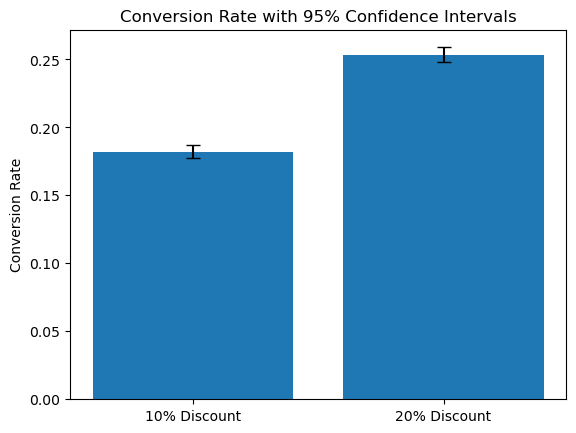

In [168]:
plt.figure()

conversion_rates = [control_conv, treatment_conv]
ci_lower = [control_ci_low, treatment_ci_low]
ci_upper = [control_ci_high, treatment_ci_high]

# Error bars
yerr = [
    [control_conv - control_ci_low, treatment_conv - treatment_ci_low],
    [control_ci_high - control_conv, treatment_ci_high - treatment_conv]
]

plt.bar(["10% Discount", "20% Discount"], conversion_rates, yerr=yerr, capsize=5)
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate with 95% Confidence Intervals")
plt.show()

## Revenue per User Comparison ##

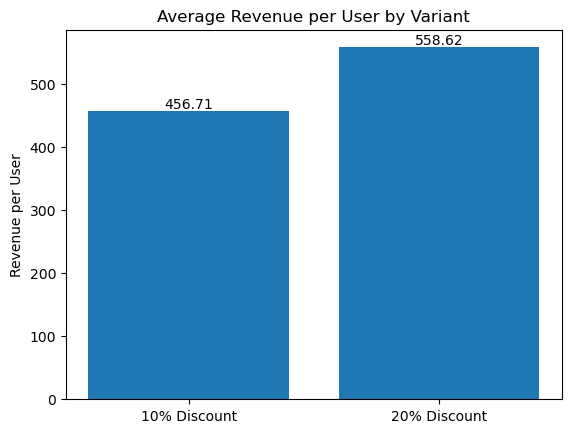

In [170]:
plt.figure()

plt.bar(
    ["10% Discount", "20% Discount"],
    [control_rpu, treatment_rpu]
)

plt.ylabel("Revenue per User")
plt.title("Average Revenue per User by Variant")

# Add labels
for i, value in enumerate([control_rpu, treatment_rpu]):
    plt.text(i, value, round(value, 2), ha="center", va="bottom")

plt.show()

In [ ]:
## Revenue Lift Visualization ##